# Comparative Analysis 1

We conducted a comparative analysis of image processing workflows created using a basic visual programming language (VPL) that directly integrates functions from multiple sources, and the same VPL enhanced with our im2im library. Additionally, we evaluated the technical demands on users when building these workflows.


**NOTE:** The Blockly library does not include an execution environment. To demonstrate and validate the functionality of our im2im library without a complex execution setup, we manually copied the generated code from the VPL interface and executed it in Google Colab. In the actual VPL, this process is handled automatically.

In [1]:
import requests

def download_file(url, save_path):
    response = requests.get(url)
    if response.status_code == 200:
        with open(save_path, 'wb') as file:
            file.write(response.content)
        print(f"File downloaded successfully and saved to {save_path}")
    else:
        print(f"Failed to download file. Status code: {response.status_code}")

In [2]:
import base64
from IPython.display import IFrame, display

def display_VPL(html_file_path, width=1200, height=900):
  with open(html_file_path, 'r') as file:
      html_content = file.read()
  html_base64 = base64.b64encode(html_content.encode()).decode()
  data_uri = f"data:text/html;base64,{html_base64}"
  display(IFrame(data_uri, width, height))

In [3]:
source_file_directory = 'https://anonymous.4open.science/r/im2im-62BB/comparative_analysis/1'

In [4]:
import os
## retinal.jpg is from scikit-image library.
test_image_path = os.path.join(source_file_directory, "retinal.jpg")
download_file(test_image_path, 'retinal.jpg')

File downloaded successfully and saved to retinal.jpg


## Base VPL4IP with Manual Conversion


In [5]:
path = 'base_VPL4IP.html'
download_file(os.path.join(source_file_directory, "base_VPL4IP.html"), path)
display_VPL(path, 1700, 1200)

File downloaded successfully and saved to base_VPL4IP.html


**Textual Code generated from the Workflow**

In [6]:
from PIL import Image
import numpy as np
from skimage.filters import sato
import cv2
from PIL import ImageDraw

raw_image = cv2.imread('retinal.jpg')

denoised = cv2.fastNlMeansDenoisingColored(raw_image, None, 10, 10, 7, 21)

sato_filtered = sato(cv2.cvtColor(denoised, cv2.COLOR_BGR2GRAY), sigmas=range(1, 10, 2), black_ridges=True)

drawn_image = Image.fromarray(sato_filtered.astype(np.uint8)).convert('RGB')
draw = ImageDraw.Draw(drawn_image)
draw.ellipse([(50, 490), (370, 810)], outline='red', width=10)

**Results Inspection**

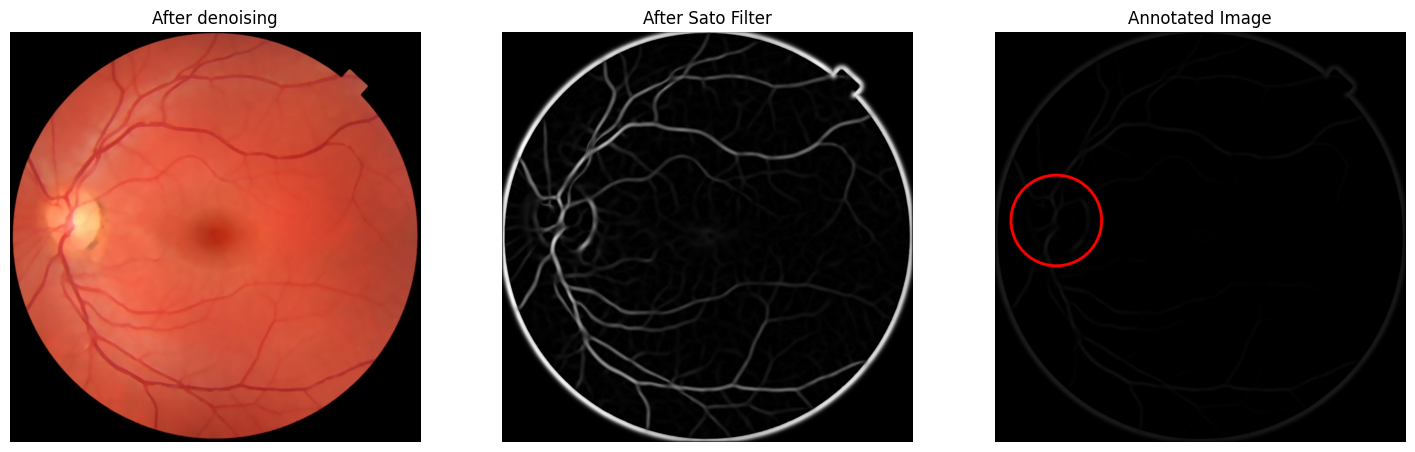

In [7]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 3, figsize=(18, 6))
ax[0].imshow(denoised[:,:,::-1])
ax[0].set_title('After denoising')
ax[0].axis('off')

ax[1].imshow(sato_filtered, cmap='gray')
ax[1].set_title('After Sato Filter')
ax[1].axis('off')

ax[2].imshow(drawn_image)
ax[2].set_title('Annotated Image')
ax[2].axis('off')

plt.show()

## Enhanced VPL4IP by our im2im library

In [8]:
# install our im2im library
!wget https://anonymous.4open.science/api/repo/im2im-62BB/zip -O im2im.zip
!unzip im2im -d /im2im
!pip install im2im

--2024-10-10 10:59:44--  https://anonymous.4open.science/api/repo/im2im-62BB/zip
Resolving anonymous.4open.science (anonymous.4open.science)... 104.21.18.195, 172.67.183.76, 2606:4700:3037::6815:12c3, ...
Connecting to anonymous.4open.science (anonymous.4open.science)|104.21.18.195|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [application/zip]
Saving to: ‘im2im.zip’

im2im.zip               [                <=> ]   2.58M   616KB/s    in 4.3s    

2024-10-10 10:59:50 (616 KB/s) - ‘im2im.zip’ saved [2710551]

Archive:  im2im.zip
  inflating: /im2im/.coveragerc      
  inflating: /im2im/.github/workflows/python tests with coverage.yml  
  inflating: /im2im/.gitignore       
  inflating: /im2im/LICENSE.txt      
  inflating: /im2im/MANIFEST.in      
  inflating: /im2im/README.md        
  inflating: /im2im/README_Dev.md    
  inflating: /im2im/comparative_analysis/1/base_VPL4IP.html  
  inflating: /im2im/comparative_analysis/1/comparative_analysis_1

In [9]:
path = 'enhanced_VPL4IP.html'
download_file(os.path.join(source_file_directory, "enhanced_VPL4IP.html"), path)
display_VPL(path, 1700, 1200)

File downloaded successfully and saved to enhanced_VPL4IP.html


**Textual Code generated from the Workflow**

In [10]:
from skimage.filters import sato
from im2im import Image, im2im
import cv2
from PIL import ImageDraw

out_im = Image(cv2.imread('retinal.jpg'), 'opencv.bgr')

in_im1 = im2im(out_im, 'opencv.bgr')
e_denoised = cv2.fastNlMeansDenoisingColored(in_im1.raw_image, None, 10, 10, 7, 21)
out_im2 = Image(e_denoised, in_im1.metadata)

in_im2 = im2im(out_im2, 'skimage.gray')
e_sato_filtered = sato(in_im2.raw_image, sigmas=range(1, 10, 2), black_ridges=True)
out_im3 = Image(e_sato_filtered, {**in_im2.metadata, 'image_data_type': 'float64'})

in_im3 = im2im(out_im3, 'pil.rgb_uint8')
e_drawn_image = in_im3.raw_image
draw = ImageDraw.Draw(e_drawn_image)
draw.ellipse([(50, 490), (370, 810)], outline='red', width=10)

out_im4 = Image(e_drawn_image, in_im3.metadata)

**Results Inspection**

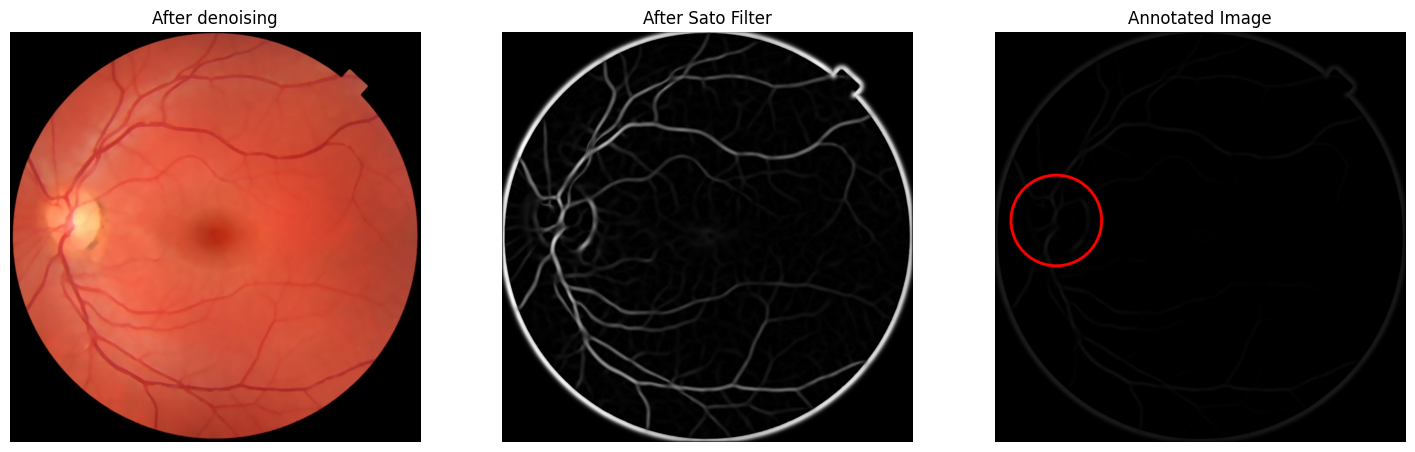

In [11]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 3, figsize=(18, 6))
ax[0].imshow(e_denoised[:,:,::-1])
ax[0].set_title('After denoising')
ax[0].axis('off')

ax[1].imshow(e_sato_filtered, cmap='gray')
ax[1].set_title('After Sato Filter')
ax[1].axis('off')

ax[2].imshow(e_drawn_image)
ax[2].set_title('Annotated Image')
ax[2].axis('off')

plt.show()

## Inspection of Results After Processing Steps

In [12]:
import numpy as np

print("Results after processing steps from base VPL4IP and enhanced VPL4IP:")
print(f"\tDenoising: {'SAME' if np.allclose(denoised, e_denoised) else 'NOT SAME'}.")
print(f"\tSato filter: {'SAME' if np.allclose(sato_filtered, e_sato_filtered) else 'NOT SAME'}.")
print(f"\tAnnotation: {'SAME' if np.allclose(drawn_image, e_drawn_image) else 'NOT SAME'}.")

Results after processing steps from base VPL4IP and enhanced VPL4IP:
	Denoising: SAME.
	Sato filter: SAME.
	Annotation: SAME.


## Inspection of Underlying Conversion Code

In [13]:
from im2im import im2im_code

# Assuming 'source' and 'target' are the names of the input and output images
print(f"Conversion Code from Denoising to Sato Filter:\n\n{im2im_code('source', out_im2.metadata, 'target', in_im2.metadata)}\n")
print(f"Conversion Code from Sato Filter to Annotation:\n\n{im2im_code('source', out_im3.metadata, 'target', in_im3.metadata)}")

Conversion Code from Denoising to Sato Filter:

import cv2
target = cv2.cvtColor(source, cv2.COLOR_BGR2GRAY)

Conversion Code from Sato Filter to Annotation:

import cv2
import numpy as np
from PIL import Image
image = source.astype(np.uint8)
image = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)
target = Image.fromarray(image)
